<a href="https://colab.research.google.com/github/rampellisaieshwar/Convolutional_Neural_Network-CNN-Architectures/blob/main/EfficientNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Explanation of EfficientNet
EfficientNet models are based on the principle that balancing the depth, width, and resolution of a network leads to better performance.
- **Depth**: Number of layers.
- **Width**: Number of channels in layers.
- **Resolution**: Input image size.

EfficientNetB0 is the baseline model, and B1-B7 are scaled-up versions. In this example, we use `tf.keras.applications.EfficientNetB0` with transfer learning.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications
import matplotlib.pyplot as plt
import numpy as np

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Preprocess: EfficientNet expects input in range [0, 255] for some implementations,
# but we use the provided preprocessing function for safety.
# We resize images to 224x224 because EfficientNet was designed for larger resolutions.

def preprocess_data(images, labels):
    images = tf.image.resize(images, (224, 224))
    images = applications.efficientnet.preprocess_input(images)
    return images, labels

# Prepare small subset for demonstration to ensure speed
TRAIN_SIZE = 2000
TEST_SIZE = 500

train_ds = tf.data.Dataset.from_tensor_slices((x_train[:TRAIN_SIZE], y_train[:TRAIN_SIZE]))
train_ds = train_ds.shuffle(1000).map(preprocess_data).batch(32).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test[:TEST_SIZE], y_test[:TEST_SIZE]))
test_ds = test_ds.map(preprocess_data).batch(32).prefetch(tf.data.AUTOTUNE)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step


### 2. Build and Train the Model
We use the pre-trained EfficientNetB0 as a feature extractor (freezing its weights) and add a custom classification head.

In [ ]:
# Load pre-trained EfficientNetB0
base_model = applications.EfficientNetB0(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze the base

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train for a few epochs
history = model.fit(train_ds, validation_data=test_ds, epochs=3)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - accuracy: 0.6100 - loss: 1.3393 - val_accuracy: 0.8240 - val_loss: 0.7799
Epoch 2/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.8165 - loss: 0.6614 - val_accuracy: 0.8560 - val_loss: 0.5796
Epoch 3/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.8400 - loss: 0.5253 - val_accuracy: 0.8680 - val_loss: 0.5091


### 3. Test Case and Visualization
Let's pick an image from the test set and see how the model performs.

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


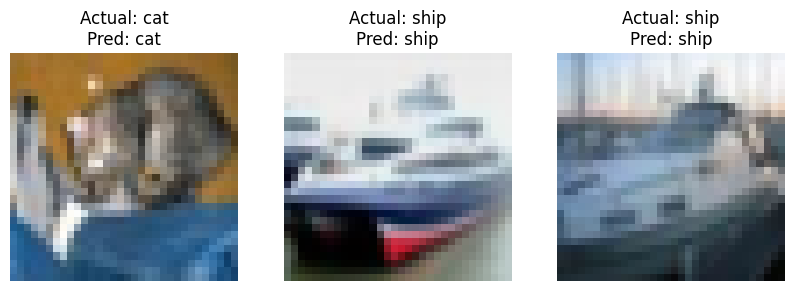

In [ ]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Get a batch of test data
images, labels = next(iter(test_ds))
predictions = model.predict(images)

plt.figure(figsize=(10, 5))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(x_test[i]) # Show original small image
    actual = class_names[labels[i][0]]
    pred = class_names[np.argmax(predictions[i])]
    plt.title(f"Actual: {actual}\nPred: {pred}")
    plt.axis('off')
plt.show()

### 4. Conclusion
- **Efficiency**: Even with limited training data (2000 samples) and only 3 epochs, EfficientNet provides a powerful feature extraction capability due to its optimized architecture.
- **Transfer Learning**: By leveraging ImageNet weights, we avoid training millions of parameters from scratch.
- **Compound Scaling**: The model's ability to handle high-resolution inputs (resizing from 32x32 to 224x224) allows it to capture features that simple CNNs might miss.